In [48]:
!pip install -q xgboost lightgbm catboost shap openpyxl

In [49]:
import os
import json
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import shap

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print("라이브러리 로드 완료")

라이브러리 로드 완료


In [50]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [51]:
DATA_PATH = "/content/drive/MyDrive/태양광_ML/land_model_data.csv"

# DATA_PATH = "/content/drive/MyDrive/태양광_ML/building_model_data.csv"

OUTPUT_DIR = "/content/drive/MyDrive/태양광_ML/model_results"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

print("입력 파일:", DATA_PATH)
print("저장 폴더:", OUTPUT_DIR)

입력 파일: /content/drive/MyDrive/태양광_ML/land_model_data.csv
저장 폴더: /content/drive/MyDrive/태양광_ML/model_results


In [52]:
file_extension = os.path.splitext(
    DATA_PATH
)[1].lower()

if file_extension == ".csv":

    try:
        df = pd.read_csv(
            DATA_PATH,
            encoding="utf-8-sig"
        )

    except UnicodeDecodeError:
        df = pd.read_csv(
            DATA_PATH,
            encoding="cp949"
        )

elif file_extension in [
    ".xlsx",
    ".xls"
]:

    df = pd.read_excel(
        DATA_PATH
    )

else:
    raise ValueError(
        f"지원하지 않는 파일 형식입니다: {file_extension}"
    )

print("데이터 크기:", df.shape)

display(
    df.head()
)

데이터 크기: (3240, 15)


,ghi_avg_daily,pvout_avg_daily,dni_avg_daily,dif_avg_daily,gti_avg_daily,slope_avg,slope_dir,elevation_avg,Hillshade,Southness,temp_avg,wind_speed_10m,wind_speed_50m,wind_speed_100m,label
0,4.1410,3.9980,3.7720,1.9550,4.8330,10.4740,251.0850,276.2540,187.7780,0.3242,12.4000,0.4903,3.6899,4.2969,0
1,4.0570,3.8150,3.2850,2.0170,4.5770,5.8960,309.6970,14.6730,196.4440,-0.6387,13.4000,1.2171,3.2138,4.3351,1
2,3.9800,3.8490,3.4100,1.9200,4.6250,8.5560,153.3070,333.4450,153.4440,0.8934,11.7000,1.1440,2.5103,3.4597,0
3,4.0280,3.9240,3.4840,1.9950,4.6960,1.4040,198.1910,7.4490,179.1110,0.9500,12.2000,2.2291,3.7798,4.6768,1
4,3.9990,3.8070,3.3740,1.9840,4.5870,4.3100,313.8650,248.8380,193.5560,-0.6930,12.6000,0.6831,3.0066,4.2241,0


In [53]:
print("컬럼 목록")

for i, col in enumerate(
    df.columns,
    start=1
):
    print(
        f"{i:02d}. {col}"
    )

컬럼 목록
01. ghi_avg_daily
02. pvout_avg_daily
03. dni_avg_daily
04. dif_avg_daily
05. gti_avg_daily
06. slope_avg
07. slope_dir
08. elevation_avg
09. Hillshade
10. Southness
11. temp_avg
12. wind_speed_10m
13. wind_speed_50m
14. wind_speed_100m
15. label


In [54]:
print("\n데이터 타입")

display(
    df.dtypes.to_frame(
        "dtype"
    )
)


데이터 타입


,dtype
ghi_avg_daily,float64
pvout_avg_daily,float64
dni_avg_daily,float64
dif_avg_daily,float64
gti_avg_daily,float64
slope_avg,float64
slope_dir,float64
elevation_avg,float64
Hillshade,float64
Southness,float64


In [55]:
print("\n결측치 개수")

missing_table = (
    df
    .isna()
    .sum()
    .sort_values(
        ascending=False
    )
    .to_frame(
        "missing_count"
    )
)

missing_table[
    "missing_ratio"
] = (
    missing_table[
        "missing_count"
    ]
    / len(df)
)

display(
    missing_table
)


결측치 개수


,missing_count,missing_ratio
ghi_avg_daily,0,0.0000
pvout_avg_daily,0,0.0000
dni_avg_daily,0,0.0000
dif_avg_daily,0,0.0000
gti_avg_daily,0,0.0000
slope_avg,0,0.0000
slope_dir,0,0.0000
elevation_avg,0,0.0000
Hillshade,0,0.0000
Southness,0,0.0000


In [56]:
FEATURE_COLUMNS = [
    "ghi_avg_daily",
    "pvout_avg_daily",
    "dni_avg_daily",
    "dif_avg_daily",
    "gti_avg_daily",
    "slope_avg",
    "slope_dir",
    "elevation_avg",
    "Hillshade",
    "Southness",
    "temp_avg",
    "wind_speed_10m",
    "wind_speed_50m",
    "wind_speed_100m"
]

TARGET_COLUMN = "label"

In [57]:
POSSIBLE_ID_COLUMNS = [
    "후보ID",
    "candidate_id",
    "Candidate_ID",
    "id",
    "ID",
    "소재지(지번)",
    "주소",
    "ltno_addr"
]

ID_COLUMNS = [
    col
    for col in POSSIBLE_ID_COLUMNS
    if col in df.columns
]

print("사용할 Feature:", FEATURE_COLUMNS)
print("Target:", TARGET_COLUMN)
print("보존할 식별 컬럼:", ID_COLUMNS)

사용할 Feature: ['ghi_avg_daily', 'pvout_avg_daily', 'dni_avg_daily', 'dif_avg_daily', 'gti_avg_daily', 'slope_avg', 'slope_dir', 'elevation_avg', 'Hillshade', 'Southness', 'temp_avg', 'wind_speed_10m', 'wind_speed_50m', 'wind_speed_100m']
Target: label
보존할 식별 컬럼: []


In [58]:
required_columns = (
    FEATURE_COLUMNS
    + [TARGET_COLUMN]
)

missing_required_columns = [
    col
    for col in required_columns
    if col not in df.columns
]

if missing_required_columns:

    raise ValueError(
        "다음 필수 컬럼이 없습니다:\n"
        + "\n".join(
            missing_required_columns
        )
    )

print("필수 컬럼 확인 완료")

필수 컬럼 확인 완료


In [59]:
model_df = df.copy()

for col in FEATURE_COLUMNS:

    model_df[col] = pd.to_numeric(
        model_df[col],
        errors="coerce"
    )

model_df[TARGET_COLUMN] = pd.to_numeric(
    model_df[TARGET_COLUMN],
    errors="coerce"
)

In [60]:
print("Label 분포")

display(
    model_df[
        TARGET_COLUMN
    ]
    .value_counts(
        dropna=False
    )
    .sort_index()
    .to_frame(
        "count"
    )
)

Label 분포


,count
label,
0,1620
1,1620


In [61]:
valid_labels = {0, 1}

actual_labels = set(
    model_df[
        TARGET_COLUMN
    ]
    .dropna()
    .unique()
)

invalid_labels = (
    actual_labels
    - valid_labels
)

if invalid_labels:

    raise ValueError(
        f"label 컬럼에 0과 1 이외의 값이 있습니다: "
        f"{invalid_labels}"
    )

print("Target 값 확인 완료")

Target 값 확인 완료


In [62]:
before_count = len(
    model_df
)

model_df = (
    model_df
    .dropna(
        subset=required_columns
    )
    .copy()
)

after_count = len(
    model_df
)

print(
    f"결측 제거 전: {before_count:,}행"
)

print(
    f"결측 제거 후: {after_count:,}행"
)

print(
    f"제거된 행: {before_count - after_count:,}행"
)

결측 제거 전: 3,240행
결측 제거 후: 3,240행
제거된 행: 0행


In [63]:
model_df[
    "original_index"
] = model_df.index

model_df.reset_index(
    drop=True,
    inplace=True
)

In [64]:
X = model_df[
    FEATURE_COLUMNS
].copy()

y = (
    model_df[
        TARGET_COLUMN
    ]
    .astype(int)
    .copy()
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3240, 14)
y shape: (3240,)


In [65]:
train_idx, test_idx = train_test_split(
    model_df.index,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

In [66]:
X_train = X.loc[
    train_idx
].copy()

X_test = X.loc[
    test_idx
].copy()

y_train = y.loc[
    train_idx
].copy()

y_test = y.loc[
    test_idx
].copy()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain label 비율")
display(
    y_train
    .value_counts(
        normalize=True
    )
    .sort_index()
)

print("\nTest label 비율")
display(
    y_test
    .value_counts(
        normalize=True
    )
    .sort_index()
)

Train shape: (2592, 14)
Test shape: (648, 14)

Train label 비율


,proportion
label,
0,0.5000
1,0.5000



Test label 비율


,proportion
label,
0,0.5000
1,0.5000


In [67]:
models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=-1,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1
    ),

    "CatBoost": CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False
    )
}

print(
    "정의된 모델:",
    list(models.keys())
)

정의된 모델: ['RandomForest', 'XGBoost', 'LightGBM', 'CatBoost']


In [68]:
trained_models = {}
evaluation_rows = []
test_prediction_table = model_df.loc[
    test_idx
].copy()

for model_name, model in models.items():

    print(
        f"\n{'=' * 60}"
    )

    print(
        f"{model_name} 학습 시작"
    )

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(
        X_test
    )

    prob = model.predict_proba(
        X_test
    )[:, 1]

    accuracy = accuracy_score(
        y_test,
        pred
    )

    precision = precision_score(
        y_test,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        prob
    )

    evaluation_rows.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc
    })

    trained_models[
        model_name
    ] = model

    test_prediction_table[
        f"{model_name}_pred"
    ] = pred

    test_prediction_table[
        f"{model_name}_prob"
    ] = prob

    print(
        classification_report(
            y_test,
            pred,
            digits=4
        )
    )

    print(
        "ROC-AUC:",
        round(
            roc_auc,
            4
        )
    )


RandomForest 학습 시작
              precision    recall  f1-score   support

           0     0.8279    0.7870    0.8070       324
           1     0.7971    0.8364    0.8163       324

    accuracy                         0.8117       648
   macro avg     0.8125    0.8117    0.8116       648
weighted avg     0.8125    0.8117    0.8116       648

ROC-AUC: 0.8998

XGBoost 학습 시작
              precision    recall  f1-score   support

           0     0.8208    0.8056    0.8131       324
           1     0.8091    0.8241    0.8165       324

    accuracy                         0.8148       648
   macro avg     0.8149    0.8148    0.8148       648
weighted avg     0.8149    0.8148    0.8148       648

ROC-AUC: 0.8944

LightGBM 학습 시작
              precision    recall  f1-score   support

           0     0.8783    0.8241    0.8503       324
           1     0.8343    0.8858    0.8593       324

    accuracy                         0.8549       648
   macro avg     0.8563    0.8549    0.8548  

In [69]:
model_comparison = pd.DataFrame(
    evaluation_rows
)

model_comparison = (
    model_comparison
    .sort_values(
        "ROC-AUC",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

display(
    model_comparison
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,LightGBM,0.8549,0.8343,0.8858,0.8593,0.9458
1,RandomForest,0.8117,0.7971,0.8364,0.8163,0.8998
2,XGBoost,0.8148,0.8091,0.8241,0.8165,0.8944
3,CatBoost,0.8148,0.7982,0.8426,0.8198,0.8896


In [70]:
comparison_path = os.path.join(
    OUTPUT_DIR,
    "model_comparison.csv"
)

model_comparison.to_csv(
    comparison_path,
    index=False,
    encoding="utf-8-sig"
)

print(
    "저장 완료:",
    comparison_path
)

저장 완료: /content/drive/MyDrive/태양광_ML/model_results/model_comparison.csv


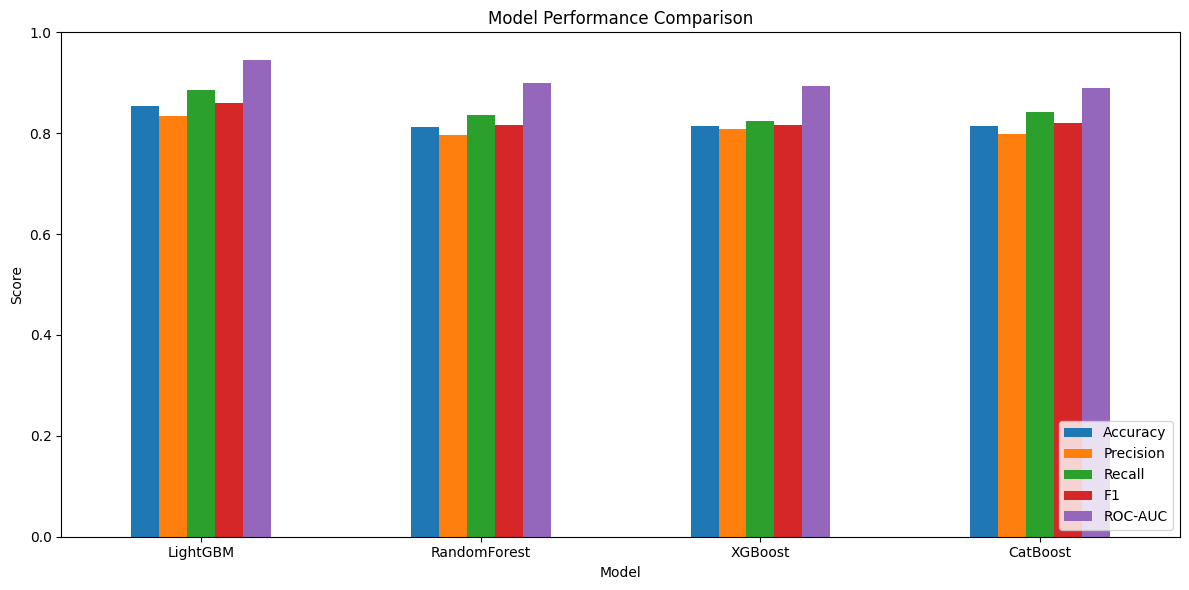

In [71]:
plot_df = (
    model_comparison
    .set_index(
        "Model"
    )[
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC-AUC"
        ]
    ]
)

ax = plot_df.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Model Performance Comparison"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Score"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=0
)

plt.legend(
    loc="lower right"
)

plt.tight_layout()
plt.show()

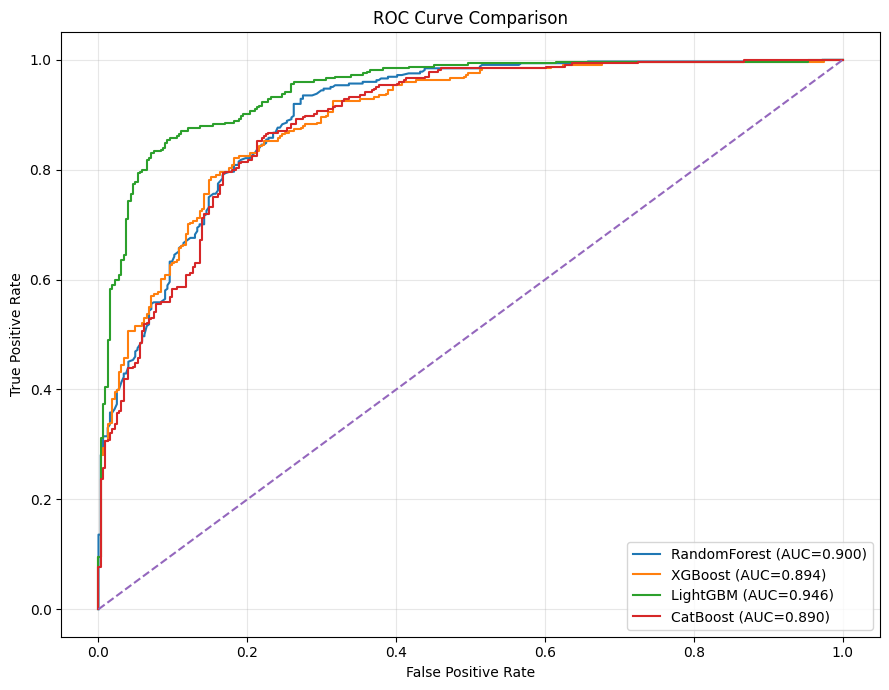

In [72]:
plt.figure(
    figsize=(9, 7)
)

for model_name in models.keys():

    prob = test_prediction_table[
        f"{model_name}_prob"
    ]

    fpr, tpr, _ = roc_curve(
        y_test,
        prob
    )

    auc_score = roc_auc_score(
        y_test,
        prob
    )

    plt.plot(
        fpr,
        tpr,
        label=(
            f"{model_name} "
            f"(AUC={auc_score:.3f})"
        )
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve Comparison"
)

plt.legend()
plt.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [73]:
best_model_name = (
    model_comparison
    .iloc[0][
        "Model"
    ]
)

best_model = trained_models[
    best_model_name
]

best_model_auc = (
    model_comparison
    .iloc[0][
        "ROC-AUC"
    ]
)

print(
    "최종 선정 모델:",
    best_model_name
)

print(
    "ROC-AUC:",
    round(
        best_model_auc,
        4
    )
)

최종 선정 모델: LightGBM
ROC-AUC: 0.9458


In [74]:
probability_columns = [
    f"{model_name}_prob"
    for model_name in models.keys()
]

In [75]:
test_prediction_table[
    "Average_Probability"
] = (
    test_prediction_table[
        probability_columns
    ]
    .mean(
        axis=1
    )
)
auc_weights = (
    model_comparison
    .set_index(
        "Model"
    )[
        "ROC-AUC"
    ]
)

auc_weights = (
    auc_weights
    / auc_weights.sum()
)

print(
    "ROC-AUC 가중치"
)

display(
    auc_weights.to_frame(
        "weight"
    )
)

weighted_probability = np.zeros(
    len(
        test_prediction_table
    )
)

for model_name in models.keys():

    weighted_probability += (
        test_prediction_table[
            f"{model_name}_prob"
        ].values
        * auc_weights[
            model_name
        ]
    )

test_prediction_table[
    "Weighted_Probability"
] = weighted_probability

test_prediction_table[
    "Prediction_Std"
] = (
    test_prediction_table[
        probability_columns
    ]
    .std(
        axis=1
    )
)

ROC-AUC 가중치


,weight
Model,
LightGBM,0.2606
RandomForest,0.2479
XGBoost,0.2464
CatBoost,0.2451


In [76]:
test_candidate_ranking = (
    test_prediction_table[
        test_prediction_table[
            TARGET_COLUMN
        ] == 0
    ]
    .copy()
)

In [77]:
test_candidate_ranking[
    "Selected_Model_Probability"
] = test_candidate_ranking[
    f"{best_model_name}_prob"
]

In [78]:
test_candidate_ranking[
    "Candidate_Rank"
] = (
    test_candidate_ranking[
        "Selected_Model_Probability"
    ]
    .rank(
        method="min",
        ascending=False
    )
    .astype(int)
)

In [79]:
test_candidate_ranking = (
    test_candidate_ranking
    .sort_values(
        "Candidate_Rank"
    )
    .reset_index(
        drop=True
    )
)

display_columns = (
    ID_COLUMNS
    + [
        "Candidate_Rank",
        "Selected_Model_Probability",
        "Average_Probability",
        "Weighted_Probability",
        "Prediction_Std"
    ]
)

display(
    test_candidate_ranking[
        display_columns
    ].head(20)
)

,Candidate_Rank,Selected_Model_Probability,Average_Probability,Weighted_Probability,Prediction_Std
0,1,0.9995,0.9886,0.9888,0.0108
1,2,0.9876,0.7856,0.7882,0.2099
2,3,0.9790,0.7633,0.7661,0.1604
3,4,0.9752,0.8983,0.8991,0.1119
4,5,0.9558,0.8810,0.8820,0.0893
5,6,0.9328,0.8470,0.8480,0.1085
6,7,0.9258,0.8304,0.8316,0.0962
7,8,0.9226,0.8458,0.8466,0.0903
8,9,0.9210,0.9006,0.9008,0.0610
9,10,0.9170,0.8922,0.8925,0.0637


In [80]:
test_ranking_path = os.path.join(
    OUTPUT_DIR,
    "test_candidate_ranking.csv"
)

test_candidate_ranking.to_csv(
    test_ranking_path,
    index=False,
    encoding="utf-8-sig"
)

print(
    "저장 완료:",
    test_ranking_path
)

저장 완료: /content/drive/MyDrive/태양광_ML/model_results/test_candidate_ranking.csv


In [81]:
final_model = models[
    best_model_name
]

final_model.fit(
    X,
    y
)

print(
    f"{best_model_name} 전체 데이터 재학습 완료"
)

LightGBM 전체 데이터 재학습 완료


In [82]:
all_probability = final_model.predict_proba(
    X
)[:, 1]

model_df[
    "Solar_Readiness_Probability"
] = all_probability

In [83]:
all_probability = final_model.predict_proba(
    X
)[:, 1]

model_df[
    "Solar_Readiness_Probability"
] = all_probability

In [85]:
candidate_ranking = (
    model_df[
        model_df[
            TARGET_COLUMN
        ] == 0
    ]
    .copy()
)

In [86]:
candidate_ranking[
    "Solar_Readiness_Score"
] = (
    candidate_ranking[
        "Solar_Readiness_Probability"
    ]
    * 100
)

In [87]:
candidate_ranking[
    "Candidate_Rank"
] = (
    candidate_ranking[
        "Solar_Readiness_Score"
    ]
    .rank(
        method="min",
        ascending=False
    )
    .astype(int)
)

In [88]:
candidate_ranking = (
    candidate_ranking
    .sort_values(
        "Candidate_Rank"
    )
    .reset_index(
        drop=True
    )
)

display(
    candidate_ranking[
        ID_COLUMNS
        + [
            "Candidate_Rank",
            "Solar_Readiness_Score"
        ]
        + FEATURE_COLUMNS
    ].head(20)
)

,Candidate_Rank,Solar_Readiness_Score,ghi_avg_daily,pvout_avg_daily,dni_avg_daily,dif_avg_daily,gti_avg_daily,slope_avg,slope_dir,elevation_avg,Hillshade,Southness,temp_avg,wind_speed_10m,wind_speed_50m,wind_speed_100m
0,1,27.5545,3.9830,3.8330,3.3530,1.9820,4.6060,8.5490,144.0010,123.9460,157.8890,0.8090,12.3000,0.3350,2.7328,3.8640
1,2,21.4413,4.0090,3.8320,3.3310,2.0000,4.5990,11.4490,50.3010,93.4890,175.0000,-0.6388,12.6000,1.1190,3.5575,4.1718
2,3,21.2669,3.9680,3.8640,3.4300,1.9750,4.6390,4.4930,115.7240,30.7930,167.1110,0.4340,12.1000,1.7458,3.0243,3.8437
3,4,20.5127,3.9860,3.7850,3.2800,1.9930,4.5610,4.5280,113.9940,127.2410,168.0000,0.4067,12.7000,0.4633,2.8398,3.8450
4,5,20.0107,3.9880,3.7780,3.3390,1.9870,4.5900,9.1720,130.8690,144.6940,153.0000,0.6543,12.5000,0.9100,1.8430,3.5356
5,6,18.6654,4.0100,3.8070,3.2830,1.9840,4.5650,10.7040,233.9850,212.6190,187.7780,0.5880,12.8000,2.3275,2.9137,4.1827
6,7,18.2994,4.0080,3.8380,3.3960,1.9960,4.6260,4.1140,253.0160,81.6120,186.0000,0.2921,12.7000,2.1601,3.5064,4.1003
7,8,17.9684,4.0410,3.7940,3.3090,1.9930,4.5890,9.7810,287.7700,141.2320,205.1110,-0.3052,13.5000,1.5786,3.1852,4.0526
8,9,17.2221,4.0010,3.8590,3.4250,1.9830,4.6470,5.8260,188.0330,67.6480,175.6670,0.9902,12.5000,0.8971,2.8404,3.4483
9,10,16.5136,4.0280,3.7710,3.3330,1.9760,4.5410,12.4850,275.3760,269.5130,187.1110,-0.0937,12.7000,0.6202,3.4544,4.5106


In [89]:
candidate_ranking[
    "Score_Percentile"
] = (
    candidate_ranking[
        "Solar_Readiness_Score"
    ]
    .rank(
        pct=True,
        ascending=True
    )
)

In [90]:
candidate_ranking[
    "Solar_Readiness_Grade"
] = pd.cut(
    candidate_ranking[
        "Score_Percentile"
    ],
    bins=[
        0,
        0.5,
        0.8,
        1.0
    ],
    labels=[
        "C",
        "B",
        "A"
    ],
    include_lowest=True
)

In [91]:
display(
    candidate_ranking[
        "Solar_Readiness_Grade"
    ]
    .value_counts()
    .sort_index()
)

,count
Solar_Readiness_Grade,
C,810
B,486
A,324


In [92]:
display(
    candidate_ranking[
        ID_COLUMNS
        + [
            "Candidate_Rank",
            "Solar_Readiness_Score",
            "Solar_Readiness_Grade"
        ]
    ].head(20)
)

,Candidate_Rank,Solar_Readiness_Score,Solar_Readiness_Grade
0,1,27.5545,A
1,2,21.4413,A
2,3,21.2669,A
3,4,20.5127,A
4,5,20.0107,A
5,6,18.6654,A
6,7,18.2994,A
7,8,17.9684,A
8,9,17.2221,A
9,10,16.5136,A


In [93]:
ranking_path = os.path.join(
    OUTPUT_DIR,
    f"{best_model_name}_all_candidate_ranking.csv"
)

candidate_ranking.to_csv(
    ranking_path,
    index=False,
    encoding="utf-8-sig"
)

print(
    "전체 후보지 순위 저장 완료:",
    ranking_path
)

전체 후보지 순위 저장 완료: /content/drive/MyDrive/태양광_ML/model_results/LightGBM_all_candidate_ranking.csv


In [94]:
model_path = os.path.join(
    OUTPUT_DIR,
    f"{best_model_name}_final_model.pkl"
)

joblib.dump(
    final_model,
    model_path
)

print(
    "모델 저장 완료:",
    model_path
)

모델 저장 완료: /content/drive/MyDrive/태양광_ML/model_results/LightGBM_final_model.pkl


In [95]:
feature_config = {
    "best_model_name": best_model_name,
    "feature_columns": FEATURE_COLUMNS,
    "target_column": TARGET_COLUMN,
    "random_state": RANDOM_STATE
}

config_path = os.path.join(
    OUTPUT_DIR,
    "model_config.json"
)

with open(
    config_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        feature_config,
        f,
        ensure_ascii=False,
        indent=2
    )

print(
    "설정 저장 완료:",
    config_path
)

설정 저장 완료: /content/drive/MyDrive/태양광_ML/model_results/model_config.json


In [96]:
SHAP_SAMPLE_SIZE = min(
    5000,
    len(X)
)

X_shap = X.sample(
    n=SHAP_SAMPLE_SIZE,
    random_state=RANDOM_STATE
)

print(
    "SHAP 분석 데이터:",
    X_shap.shape
)

SHAP 분석 데이터: (3240, 14)


In [97]:
explainer = shap.TreeExplainer(
    final_model
)

shap_result = explainer(
    X_shap
)

print(
    "SHAP 계산 완료"
)

print(
    "SHAP raw shape:",
    shap_result.values.shape
)

SHAP 계산 완료
SHAP raw shape: (3240, 14)


In [98]:
shap_values_raw = shap_result.values

if shap_values_raw.ndim == 3:

    shap_values = (
        shap_values_raw[
            :,
            :,
            1
        ]
    )

else:

    shap_values = (
        shap_values_raw
    )

print(
    "정리된 SHAP shape:",
    shap_values.shape
)

print(
    "X_shap shape:",
    X_shap.shape
)

정리된 SHAP shape: (3240, 14)
X_shap shape: (3240, 14)


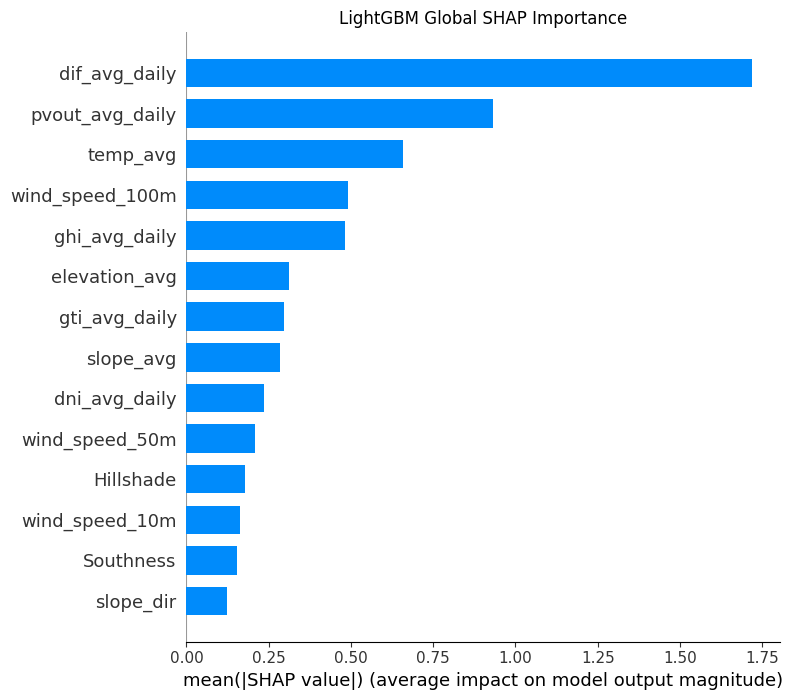

In [99]:
shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    show=False
)

plt.title(
    f"{best_model_name} Global SHAP Importance"
)

plt.tight_layout()
plt.show()

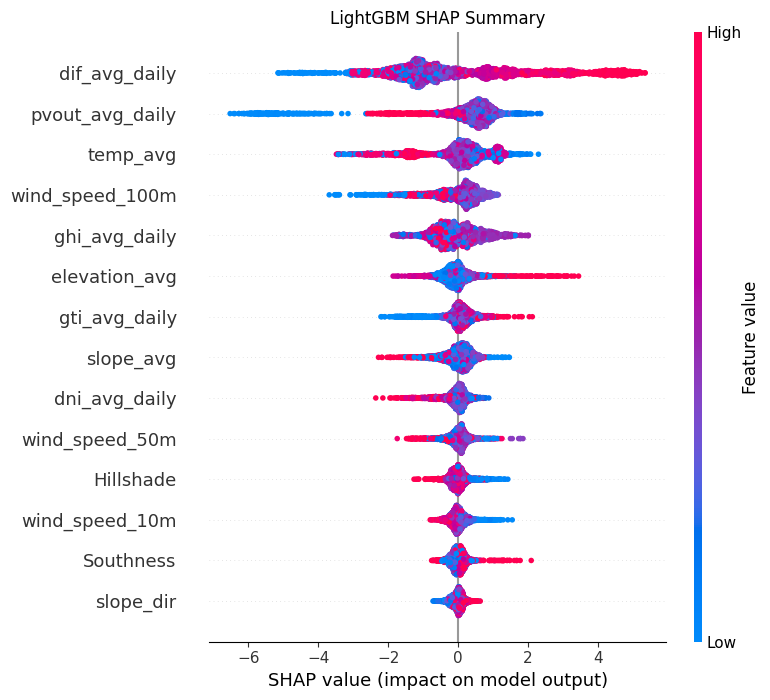

In [100]:
shap.summary_plot(
    shap_values,
    X_shap,
    show=False
)

plt.title(
    f"{best_model_name} SHAP Summary"
)

plt.tight_layout()
plt.show()

In [101]:
SHAP_TOP_N = min(
    1000,
    len(
        candidate_ranking
    )
)

top_candidates = (
    candidate_ranking
    .head(
        SHAP_TOP_N
    )
    .copy()
)

In [102]:
X_candidates_shap = top_candidates[
    FEATURE_COLUMNS
].copy()

In [103]:
candidate_shap_result = explainer(
    X_candidates_shap
)

candidate_shap_raw = (
    candidate_shap_result.values
)

if candidate_shap_raw.ndim == 3:

    candidate_shap_values = (
        candidate_shap_raw[
            :,
            :,
            1
        ]
    )

else:

    candidate_shap_values = (
        candidate_shap_raw
    )

print(
    "후보지 SHAP shape:",
    candidate_shap_values.shape
)

후보지 SHAP shape: (1000, 14)


In [104]:
candidate_position = 0

In [105]:
base_values_raw = (
    candidate_shap_result.base_values
)

if np.ndim(
    base_values_raw
) == 2:

    candidate_base_value = (
        base_values_raw[
            candidate_position,
            1
        ]
    )

elif np.ndim(
    base_values_raw
) == 1:

    candidate_base_value = (
        base_values_raw[
            candidate_position
        ]
    )

else:

    candidate_base_value = (
        base_values_raw
    )

In [106]:
candidate_explanation = shap.Explanation(
    values=(
        candidate_shap_values[
            candidate_position
        ]
    ),
    base_values=candidate_base_value,
    data=(
        X_candidates_shap
        .iloc[
            candidate_position
        ]
        .values
    ),
    feature_names=FEATURE_COLUMNS
)

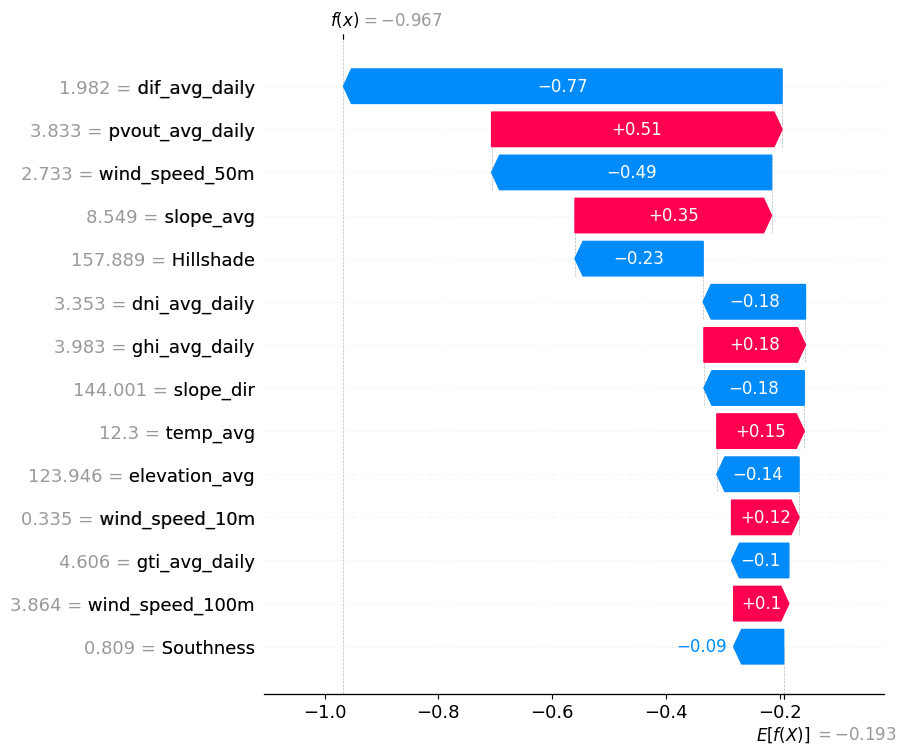

In [107]:
shap.plots.waterfall(
    candidate_explanation,
    max_display=14
)

In [108]:
FEATURE_KOREAN_NAMES = {
    "ghi_avg_daily": "수평면 전일사량",
    "pvout_avg_daily": "예상 태양광 발전량",
    "dni_avg_daily": "직달일사량",
    "dif_avg_daily": "산란일사량",
    "gti_avg_daily": "경사면 일사량",
    "slope_avg": "평균 경사도",
    "slope_dir": "평균 경사 방향",
    "elevation_avg": "평균 고도",
    "Hillshade": "지형 음영도",
    "Southness": "남향성",
    "temp_avg": "평균 기온",
    "wind_speed_10m": "10m 높이 풍속",
    "wind_speed_50m": "50m 높이 풍속",
    "wind_speed_100m": "100m 높이 풍속"
}

In [109]:
candidate_reference = (
    candidate_ranking[
        FEATURE_COLUMNS
    ]
    .copy()
)

In [110]:
percentile_df = pd.DataFrame(
    index=top_candidates.index
)

for col in FEATURE_COLUMNS:

    percentile_df[col] = (
        candidate_reference[col]
        .rank(
            pct=True
        )
        .loc[
            top_candidates.index
        ]
        * 100
    )

In [111]:
percentile_df = pd.DataFrame(
    index=top_candidates.index
)

for col in FEATURE_COLUMNS:

    percentile_df[col] = (
        candidate_reference[col]
        .rank(
            pct=True
        )
        .loc[
            top_candidates.index
        ]
        * 100
    )

In [112]:
shap_reason_rows = []

for position in range(
    len(
        top_candidates
    )
):

    candidate_row = (
        top_candidates
        .iloc[
            position
        ]
    )

    one_candidate = pd.DataFrame({
        "Feature": FEATURE_COLUMNS,
        "Feature_Value": (
            X_candidates_shap
            .iloc[
                position
            ]
            .values
        ),
        "SHAP_Value": (
            candidate_shap_values[
                position
            ]
        )
    })

    one_candidate[
        "Abs_SHAP"
    ] = (
        one_candidate[
            "SHAP_Value"
        ]
        .abs()
    )

    one_candidate = (
        one_candidate[
            one_candidate[
                "SHAP_Value"
            ] > 0
        ]
        .sort_values(
            "Abs_SHAP",
            ascending=False
        )
        .head(3)
        .copy()
    )

    for reason_rank, (_, reason) in enumerate(
        one_candidate.iterrows(),
        start=1
    ):

        feature = reason[
            "Feature"
        ]

        shap_reason_rows.append({
            "Candidate_Rank": candidate_row[
                "Candidate_Rank"
            ],
            "original_index": candidate_row[
                "original_index"
            ],
            "Reason_Rank": reason_rank,
            "Feature": feature,
            "Feature_Korean": FEATURE_KOREAN_NAMES.get(
                feature,
                feature
            ),
            "Feature_Value": reason[
                "Feature_Value"
            ],
            "SHAP_Value": reason[
                "SHAP_Value"
            ],
            "Percentile": percentile_df.iloc[
                position
            ][feature]
        })

candidate_shap_reasons = pd.DataFrame(
    shap_reason_rows
)

display(
    candidate_shap_reasons.head(15)
)

,Candidate_Rank,original_index,Reason_Rank,Feature,Feature_Korean,Feature_Value,SHAP_Value,Percentile
0,1,1548,1,pvout_avg_daily,예상 태양광 발전량,3.8330,0.5105,50.8951
1,1,1548,2,slope_avg,평균 경사도,8.5490,0.3454,55.4321
2,1,1548,3,ghi_avg_daily,수평면 전일사량,3.9830,0.1785,27.6235
3,2,1950,1,pvout_avg_daily,예상 태양광 발전량,3.8320,0.5567,50.4012
4,2,1950,2,temp_avg,평균 기온,12.6000,0.2248,31.2346
5,2,1950,3,wind_speed_10m,10m 높이 풍속,1.1190,0.1000,29.1975
6,3,1497,1,temp_avg,평균 기온,12.1000,0.5217,17.2840
7,3,1497,2,pvout_avg_daily,예상 태양광 발전량,3.8640,0.3300,64.5679
8,4,307,1,pvout_avg_daily,예상 태양광 발전량,3.7850,0.3379,28.2407
9,4,307,2,wind_speed_100m,100m 높이 풍속,3.8450,0.1129,23.7654


In [113]:
LOWER_IS_FAVORABLE = {
    "slope_avg"
}

HIGHER_IS_FAVORABLE = {
    "ghi_avg_daily",
    "pvout_avg_daily",
    "dni_avg_daily",
    "dif_avg_daily",
    "gti_avg_daily",
    "Southness"
}

In [114]:
def create_reason_sentence(
    feature,
    feature_name,
    feature_value,
    percentile
):

    if feature in LOWER_IS_FAVORABLE:

        reverse_percentile = (
            100
            - percentile
        )

        return (
            f"{feature_name}가 {feature_value:.2f}로 "
            f"전체 후보지 중 완만한 상위 "
            f"{reverse_percentile:.1f}% 수준이며, "
            f"모델의 추천 점수를 높인 주요 요인입니다."
        )

    elif feature in HIGHER_IS_FAVORABLE:

        top_percent = (
            100
            - percentile
        )

        return (
            f"{feature_name}가 {feature_value:.2f}로 "
            f"전체 후보지 상위 "
            f"{top_percent:.1f}% 수준이며, "
            f"모델의 추천 점수를 높인 주요 요인입니다."
        )

    else:

        return (
            f"{feature_name} 값 {feature_value:.2f}이 "
            f"해당 후보지의 모델 추천 점수를 "
            f"높인 주요 요인으로 분석되었습니다."
        )

In [115]:
candidate_shap_reasons[
    "Reason_Text"
] = candidate_shap_reasons.apply(
    lambda row: create_reason_sentence(
        feature=row[
            "Feature"
        ],
        feature_name=row[
            "Feature_Korean"
        ],
        feature_value=row[
            "Feature_Value"
        ],
        percentile=row[
            "Percentile"
        ]
    ),
    axis=1
)

display(
    candidate_shap_reasons[
        [
            "Candidate_Rank",
            "Reason_Rank",
            "Feature_Korean",
            "SHAP_Value",
            "Reason_Text"
        ]
    ].head(15)
)

,Candidate_Rank,Reason_Rank,Feature_Korean,SHAP_Value,Reason_Text
0,1,1,예상 태양광 발전량,0.5105,"예상 태양광 발전량가 3.83로 전체 후보지 상위 49.1% 수준이며, 모델의 추천..."
1,1,2,평균 경사도,0.3454,"평균 경사도가 8.55로 전체 후보지 중 완만한 상위 44.6% 수준이며, 모델의 ..."
2,1,3,수평면 전일사량,0.1785,"수평면 전일사량가 3.98로 전체 후보지 상위 72.4% 수준이며, 모델의 추천 점..."
3,2,1,예상 태양광 발전량,0.5567,"예상 태양광 발전량가 3.83로 전체 후보지 상위 49.6% 수준이며, 모델의 추천..."
4,2,2,평균 기온,0.2248,평균 기온 값 12.60이 해당 후보지의 모델 추천 점수를 높인 주요 요인으로 분석...
5,2,3,10m 높이 풍속,0.1000,10m 높이 풍속 값 1.12이 해당 후보지의 모델 추천 점수를 높인 주요 요인으로...
6,3,1,평균 기온,0.5217,평균 기온 값 12.10이 해당 후보지의 모델 추천 점수를 높인 주요 요인으로 분석...
7,3,2,예상 태양광 발전량,0.3300,"예상 태양광 발전량가 3.86로 전체 후보지 상위 35.4% 수준이며, 모델의 추천..."
8,4,1,예상 태양광 발전량,0.3379,"예상 태양광 발전량가 3.79로 전체 후보지 상위 71.8% 수준이며, 모델의 추천..."
9,4,2,100m 높이 풍속,0.1129,100m 높이 풍속 값 3.85이 해당 후보지의 모델 추천 점수를 높인 주요 요인으...


In [116]:
reason_wide = (
    candidate_shap_reasons
    .pivot(
        index="original_index",
        columns="Reason_Rank",
        values="Reason_Text"
    )
    .rename(
        columns={
            1: "추천이유_1",
            2: "추천이유_2",
            3: "추천이유_3"
        }
    )
    .reset_index()
)

In [117]:
feature_wide = (
    candidate_shap_reasons
    .pivot(
        index="original_index",
        columns="Reason_Rank",
        values="Feature_Korean"
    )
    .rename(
        columns={
            1: "추천요인_1",
            2: "추천요인_2",
            3: "추천요인_3"
        }
    )
    .reset_index()
)

In [118]:
top_candidates_with_reasons = (
    top_candidates
    .merge(
        reason_wide,
        on="original_index",
        how="left"
    )
    .merge(
        feature_wide,
        on="original_index",
        how="left"
    )
)

In [119]:
display(
    top_candidates_with_reasons[
        ID_COLUMNS
        + [
            "Candidate_Rank",
            "Solar_Readiness_Score",
            "Solar_Readiness_Grade",
            "추천요인_1",
            "추천이유_1",
            "추천요인_2",
            "추천이유_2",
            "추천요인_3",
            "추천이유_3"
        ]
    ].head(20)
)

,Candidate_Rank,Solar_Readiness_Score,Solar_Readiness_Grade,추천요인_1,추천이유_1,추천요인_2,추천이유_2,추천요인_3,추천이유_3
0,1,27.5545,A,예상 태양광 발전량,"예상 태양광 발전량가 3.83로 전체 후보지 상위 49.1% 수준이며, 모델의 추천...",평균 경사도,"평균 경사도가 8.55로 전체 후보지 중 완만한 상위 44.6% 수준이며, 모델의 ...",수평면 전일사량,"수평면 전일사량가 3.98로 전체 후보지 상위 72.4% 수준이며, 모델의 추천 점..."
1,2,21.4413,A,예상 태양광 발전량,"예상 태양광 발전량가 3.83로 전체 후보지 상위 49.6% 수준이며, 모델의 추천...",평균 기온,평균 기온 값 12.60이 해당 후보지의 모델 추천 점수를 높인 주요 요인으로 분석...,10m 높이 풍속,10m 높이 풍속 값 1.12이 해당 후보지의 모델 추천 점수를 높인 주요 요인으로...
2,3,21.2669,A,평균 기온,평균 기온 값 12.10이 해당 후보지의 모델 추천 점수를 높인 주요 요인으로 분석...,예상 태양광 발전량,"예상 태양광 발전량가 3.86로 전체 후보지 상위 35.4% 수준이며, 모델의 추천...",NaN,NaN
3,4,20.5127,A,예상 태양광 발전량,"예상 태양광 발전량가 3.79로 전체 후보지 상위 71.8% 수준이며, 모델의 추천...",100m 높이 풍속,100m 높이 풍속 값 3.85이 해당 후보지의 모델 추천 점수를 높인 주요 요인으...,10m 높이 풍속,10m 높이 풍속 값 0.46이 해당 후보지의 모델 추천 점수를 높인 주요 요인으로...
4,5,20.0107,A,평균 경사도,"평균 경사도가 9.17로 전체 후보지 중 완만한 상위 41.7% 수준이며, 모델의 ...",예상 태양광 발전량,"예상 태양광 발전량가 3.78로 전체 후보지 상위 74.3% 수준이며, 모델의 추천...",10m 높이 풍속,10m 높이 풍속 값 0.91이 해당 후보지의 모델 추천 점수를 높인 주요 요인으로...
5,6,18.6654,A,평균 경사도,"평균 경사도가 10.70로 전체 후보지 중 완만한 상위 34.5% 수준이며, 모델의...",100m 높이 풍속,100m 높이 풍속 값 4.18이 해당 후보지의 모델 추천 점수를 높인 주요 요인으...,남향성,"남향성가 0.59로 전체 후보지 상위 33.5% 수준이며, 모델의 추천 점수를 높인..."
6,7,18.2994,A,예상 태양광 발전량,"예상 태양광 발전량가 3.84로 전체 후보지 상위 46.4% 수준이며, 모델의 추천...",100m 높이 풍속,100m 높이 풍속 값 4.10이 해당 후보지의 모델 추천 점수를 높인 주요 요인으...,평균 기온,평균 기온 값 12.70이 해당 후보지의 모델 추천 점수를 높인 주요 요인으로 분석...
7,8,17.9684,A,예상 태양광 발전량,"예상 태양광 발전량가 3.79로 전체 후보지 상위 68.6% 수준이며, 모델의 추천...",100m 높이 풍속,100m 높이 풍속 값 4.05이 해당 후보지의 모델 추천 점수를 높인 주요 요인으...,평균 고도,평균 고도 값 141.23이 해당 후보지의 모델 추천 점수를 높인 주요 요인으로 분...
8,9,17.2221,A,예상 태양광 발전량,"예상 태양광 발전량가 3.86로 전체 후보지 상위 37.5% 수준이며, 모델의 추천...",평균 기온,평균 기온 값 12.50이 해당 후보지의 모델 추천 점수를 높인 주요 요인으로 분석...,평균 경사도,"평균 경사도가 5.83로 전체 후보지 중 완만한 상위 58.4% 수준이며, 모델의 ..."
9,10,16.5136,A,예상 태양광 발전량,"예상 태양광 발전량가 3.77로 전체 후보지 상위 77.0% 수준이며, 모델의 추천...",100m 높이 풍속,100m 높이 풍속 값 4.51이 해당 후보지의 모델 추천 점수를 높인 주요 요인으...,50m 높이 풍속,50m 높이 풍속 값 3.45이 해당 후보지의 모델 추천 점수를 높인 주요 요인으로...


In [120]:
shap_result_path = os.path.join(
    OUTPUT_DIR,
    f"{best_model_name}_top_candidates_with_shap.csv"
)

top_candidates_with_reasons.to_csv(
    shap_result_path,
    index=False,
    encoding="utf-8-sig"
)

print(
    "SHAP 추천 결과 저장 완료:",
    shap_result_path
)

SHAP 추천 결과 저장 완료: /content/drive/MyDrive/태양광_ML/model_results/LightGBM_top_candidates_with_shap.csv


In [121]:
shap_detail_path = os.path.join(
    OUTPUT_DIR,
    f"{best_model_name}_candidate_shap_details.csv"
)

candidate_shap_reasons.to_csv(
    shap_detail_path,
    index=False,
    encoding="utf-8-sig"
)

print(
    "SHAP 세부 결과 저장 완료:",
    shap_detail_path
)

SHAP 세부 결과 저장 완료: /content/drive/MyDrive/태양광_ML/model_results/LightGBM_candidate_shap_details.csv


In [122]:
result_files = [
    comparison_path,
    test_ranking_path,
    ranking_path,
    model_path,
    config_path,
    shap_result_path,
    shap_detail_path
]

for path in result_files:

    print(
        os.path.basename(path),
        "→",
        os.path.exists(path)
    )

model_comparison.csv → True
test_candidate_ranking.csv → True
LightGBM_all_candidate_ranking.csv → True
LightGBM_final_model.pkl → True
model_config.json → True
LightGBM_top_candidates_with_shap.csv → True
LightGBM_candidate_shap_details.csv → True
